In [22]:
import os
from dotenv import load_dotenv
from typing import Annotated,Literal, NotRequired
from typing_extensions import TypedDict
load_dotenv()

True

In [23]:

class Todo(TypedDict):
    """A structured task item for tracking progress through complex workflows.

    Attributes:
        content: Short, specific description of the task
        status: Current state - pending, in_progress, or completed
    """
    content:str
    status: Literal["pending", "in_progress", "completed"]

In [24]:
def file_reducer(left, right):
    """Merge two file dictionaries, with right side taking precedence.

    Used as a reducer function for the files field in agent state,
    allowing incremental updates to the virtual file system.

    Args:
        left: Left side dictionary (existing files)
        right: Right side dictionary (new/updated files)

    Returns:
        Merged dictionary with right values overriding left values
    """
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}

In [25]:
from langchain.agents import AgentState
class DeepAgentState(AgentState):
    """Extended agent state that includes task tracking and virtual file system.

    Inherits from LangGraph's AgentState and adds:
    - todos: List of Todo items for task planning and progress tracking
    - files: Virtual file system stored as dict mapping filenames to content
    """
    todo: NotRequired[list[Todo]]
    files:Annotated[NotRequired[dict[str,str]],file_reducer]
print(DeepAgentState)

<class '__main__.DeepAgentState'>


### Create Tools

In [26]:
from utils import show_prompt


In [27]:
from prompts import WRITE_TODOS_DESCRIPTION

In [28]:
show_prompt(WRITE_TODOS_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Create and manage structured task lists for tracking progress through complex workflows.                       │
│                                                                                                                 │
│  ## When to Use                                                                                                 │
│  - Multi-step or non-trivial tasks requiring coordination                                                       │
│  - When user provides multiple tasks or explicitly requests todo list                                           │
│  - Avoid for single, trivial actions unless directed otherwise                                                  │
│                                                                                                                 │
│  ## Structure                                                                                                   │
│  - Maintain one list containing multiple todo objects (content, status, id)                                     │
│  - Use clear, actionable content descriptions                                                                   │
│  - Status must be: pending, in_progress, or completed                                                           │
│                                                                                                                 │
│  ## Best Practices                                                                                              │
│  - Only one in_progress task at a time                                                                          │
│  - Mark completed immediately when task is fully done                                                           │
│  - Always send the full updated list when making changes                                                        │
│  - Prune irrelevant items to keep list focused                                                                  │
│                                                                                                                 │
│  ## Progress Updates                                                                                            │
│  - Call TodoWrite again to change task status or edit content                                                   │
│  - Reflect real-time progress; don't batch completions                                                          │
│  - If blocked, keep in_progress and add new task describing blocker                                             │
│                                                                                                                 │
│  ## Parameters                                                                                                  │
│  - todos: List of TODO items with content and status fields                                                     │
│                                                                                                                 │
│  ## Returns                                                                                                     │
│  Updates agent state with new todo list.                                                                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [29]:
from langchain_core.messages import ToolMessage
from langgraph.types import Command
from langchain_core.tools import InjectedToolCallId, tool


@tool(description=WRITE_TODOS_DESCRIPTION,parse_docstring=True)
def write_todos(
    todos : list[Todo],
    tool_call_id: Annotated[str,InjectedToolCallId]
) -> Command:
    """Create or update the agent's TODO list for task planning and tracking.

    Args:
        todos: List of Todo items with content and status
        tool_call_id: Tool call identifier for message response

    Returns:
        Command to update agent state with new TODO list
    """
    return Command(
        update={
            "todos":todos,
            "messages":[
                ToolMessage(f"Updated todo list to: {todos}",tool_call_id=tool_call_id)
            ]
            
        }
    )

In [30]:
from langgraph.prebuilt import InjectedState
@tool(parse_docstring=True)
def read_todos(
    state : Annotated[DeepAgentState,InjectedState],
    tool_call_id : Annotated[str, InjectedToolCallId]
) -> str:
    """Read the current TODO list from the agent state.

    This tool allows the agent to retrieve and review the current TODO list
    to stay focused on remaining tasks and track progress through complex workflows.

    Args:
        state: Injected agent state containing the current TODO list
        

    Returns:
        Formatted string representation of the current TODO list
    """
    todos = state.get("todos",[])
    if not todos:
        return "No available todos in the list"
    
    result = "Current TODO List:\n"

    for i,todo in enumerate(todos,1): #type: ignore
        status_emoji = {"pending": "⏳", "in_progress": "🔄", "completed": "✅"}
        emoji =status_emoji.get(todo['status'],"?")
        result +=f"{i}, {emoji} {todo['content']} ({todo['status']})\n"
    
    return result.strip()


In [31]:
from prompts import TODO_USAGE_INSTRUCTIONS

In [32]:
show_prompt(TODO_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Based upon the user's request:                                                                                 │
│  1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.           │
│  2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan.  │
│  3. Reflect on what you've done and the TODO.                                                                   │
│  4. Mark you task as completed, and proceed to the next TODO.                                                   │
│  5. Continue this process until you have completed all TODOs.                                                   │
│                                                                                                                 │
│  IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY  │
│  user request.                                                                                                  │
│  IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have  │
│  to keep track of.                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [33]:
# Mock search result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """

In [34]:
@tool(parse_docstring=True)
def web_search(
    query:str
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result

In [35]:
tools = [write_todos,read_todos,web_search]

In [36]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(
    model='google_genai:gemini-2.5-flash',
    temperature=0.0
)

In [37]:
# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the user's question."""

In [38]:
from langchain.agents import create_agent
agent = create_agent(
    model=llm,
    tools=tools,
    state_schema=DeepAgentState,
    system_prompt=TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + SIMPLE_RESEARCH_INSTRUCTIONS
)

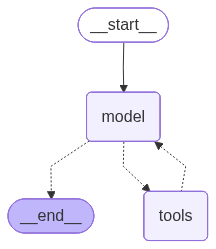

In [39]:
from IPython.display import Image,display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [40]:
from utils import format_messages
result = agent.invoke(
    {
        "messages":[
            {
                "role":"user",
                "content":"Give me a short summary of the Model Context Protocol (MCP)"
            }
        ],
        "todos":[],
    }
)
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me a short summary of the Model Context Protocol (MCP)                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Search for \"Model Context Protocol (MCP)\" on the web.",                                     │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "status": "pending",                                                                                      │
│       "content": "Summarize the information found about MCP."                                                   │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: d0705645-f196-4849-83d5-a81f89400cc7                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to: [{'content': 'Search for "Model Context Protocol (MCP)" on the web.', 'status':           │
│ 'pending'}, {'content': 'Summarize the information found about MCP.', 'status': 'pending'}]                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "status": "in_progress",                                                                                  │
│       "content": "Search for \"Model Context Protocol (MCP)\" on the web."                                      │
│     },                                                                                                          │
│     {                                                                                                           │
│       "status": "pending",                                                                                      │
│       "content": "Summarize the information found about MCP."                                                   │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: 45573981-1287-4a98-b68a-5c190b46530f                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to: [{'content': 'Search for "Model Context Protocol (MCP)" on the web.', 'status':           │
│ 'in_progress'}, {'content': 'Summarize the information found about MCP.', 'status': 'pending'}]                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Search for \"Model Context Protocol (MCP)\" on the web.",                                     │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "status": "in_progress",                                                                                  │
│       "content": "Summarize the information found about MCP."                                                   │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: b2499194-da94-4616-bee1-fdafb1c4b844                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to: [{'content': 'Search for "Model Context Protocol (MCP)" on the web.', 'status':           │
│ 'completed'}, {'content': 'Summarize the information found about MCP.', 'status': 'in_progress'}]               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The Model Context Protocol (MCP) is an open standard protocol created by Anthropic. It serves as a standardized │
│ communication layer to enable AI models to seamlessly integrate with and access data from external systems like │
│ tools, databases, and other services. Essentially, MCP simplifies the process of connecting AI assistants to    │
│ external services by providing a unified language for data exchange, allowing for consistent and efficient data │
│ utilization.                                                                                                    │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Search for \"Model Context Protocol (MCP)\" on the web.",                                     │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Summarize the information found about MCP.",                                                  │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: b95a3875-191e-4f6a-b684-06ace8453105                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to: [{'content': 'Search for "Model Context Protocol (MCP)" on the web.', 'status':           │
│ 'completed'}, {'content': 'Summarize the information found about MCP.', 'status': 'completed'}]                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The Model Context Protocol (MCP) is an open standard protocol developed by Anthropic. Its purpose is to         │
│ facilitate seamless integration between AI models and external systems such as tools, databases, and other      │
│ services. MCP acts as a standardized communication layer, enabling AI models to access and utilize data from    │
│ diverse sources consistently and efficiently. In essence, it simplifies the process of connecting AI assistants │
│ to external services by providing a unified language for data exchange.                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯